## NFL Game Replay & Prediction Engine!
#### Predicting whether an NFL team will run or pass depending on game context, including down, distance, time, and score.

### Part 1: Data Collection

In [1]:
import pandas as pd
%pip install nflreadpy
import nflreadpy as nfl

Note: you may need to restart the kernel to use updated packages.


In [2]:
# now we can snag the play by play data
pbp = nfl.load_pbp([2021, 2022, 2023, 2024, 2025])
pbp.head()

play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,…,home_coach,away_coach,stadium_id,game_stadium,aborted_play,success,passer,passer_jersey_number,rusher,rusher_jersey_number,receiver,receiver_jersey_number,pass,rush,first_down,special,play,passer_id,rusher_id,receiver_id,name,jersey_number,id,fantasy_player_name,fantasy_player_id,fantasy,fantasy_id,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
f64,str,str,str,str,str,i32,str,str,str,str,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,…,str,str,str,str,f64,f64,str,i32,str,i32,str,i32,f64,f64,f64,f64,f64,str,str,str,str,i32,str,str,str,str,str,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64
1.0,"""2021_01_ARI_TEN""","""2021091207""","""TEN""","""ARI""","""REG""",1,null,null,null,null,null,"""2021-09-12""",900.0,1800.0,3600.0,"""Half1""",0.0,null,0.0,1.0,null,0.0,"""15:00""","""ARI 35""",0.0,null,"""GAME""",null,null,0.0,0.0,null,0.0,0.0,0.0,null,…,"""Mike Vrabel""","""Kliff Kingsbury""","""NAS00""","""Nissan Stadium""",0.0,0.0,null,null,null,null,null,null,0.0,0.0,null,0.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,1.0,0.0,null,null,null,null,null,null,null
40.0,"""2021_01_ARI_TEN""","""2021091207""","""TEN""","""ARI""","""REG""",1,"""TEN""","""home""","""ARI""","""ARI""",35.0,"""2021-09-12""",900.0,1800.0,3600.0,"""Half1""",0.0,1.0,0.0,1.0,null,0.0,"""15:00""","""ARI 35""",0.0,0.0,"""5-M.Prater kicks 65 yards from…","""kickoff""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Mike Vrabel""","""Kliff Kingsbury""","""NAS00""","""Nissan Stadium""",0.0,0.0,null,null,null,null,null,null,0.0,0.0,0.0,1.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,1.0,0.0,null,null,null,null,null,null,null
55.0,"""2021_01_ARI_TEN""","""2021091207""","""TEN""","""ARI""","""REG""",1,"""TEN""","""home""","""ARI""","""TEN""",75.0,"""2021-09-12""",900.0,1800.0,3600.0,"""Half1""",0.0,1.0,0.0,1.0,1.0,0.0,"""15:00""","""TEN 25""",10.0,0.0,"""(15:00) 22-D.Henry left tackle…","""run""",-3.0,0.0,0.0,0.0,0.0,0.0,0.0,null,…,"""Mike Vrabel""","""Kliff Kingsbury""","""NAS00""","""Nissan Stadium""",0.0,0.0,null,null,"""D.Henry""",22,null,null,0.0,1.0,0.0,0.0,1.0,null,"""00-0032764""",null,"""D.Henry""",22,"""00-0032764""","""D.Henry""","""00-0032764""","""D.Henry""","""00-0032764""",0.0,1.0,-1.399805,null,null,null,null,null,0.491433,-49.143299
76.0,"""2021_01_ARI_TEN""","""2021091207""","""TEN""","""ARI""","""REG""",1,"""TEN""","""home""","""ARI""","""TEN""",78.0,"""2021-09-12""",863.0,1763.0,3563.0,"""Half1""",0.0,1.0,0.0,1.0,2.0,0.0,"""14:23""","""TEN 22""",13.0,0.0,"""(14:23) (Shotgun) 17-R.Tannehi…","""pass""",3.0,1.0,0.0,1.0,0.0,0.0,0.0,"""short""",…,"""Mike Vrabel""","""Kliff Kingsbury""","""NAS00""","""Nissan Stadium""",0.0,1.0,"""R.Tannehill""",17,null,null,"""D.Henry""",22,1.0,0.0,0.0,0.0,1.0,"""00-0029701""",null,"""00-0032764""","""R.Tannehill""",17,"""00-0029701""","""D.Henry""","""00-0032764""","""D.Henry""","""00-0032764""",0.0,1.0,0.032412,1.165133,5.803177,4,0.896654,0.125098,0.697346,30.265415
100.0,"""2021_01_ARI_TEN""","""2021091207""","""TEN""","""ARI""","""REG""",1,"""TEN""","""home""","""ARI""","""TEN""",75.0,"""2021-09-12""",822.0,1722.0,3522.0,"""Half1""",0.0,1.0,0.0,1.0,3.0,0.0,"""13:42""","""TEN 25""",10.0,0.0,"""(13:42) (Shotgun) 17-R.Tannehi…","""pass""",0.0,1.0,0.0,1.0,0.0,0.0,0.0,"""short""",…,"""Mike Vrabel""","""Kliff Kingsbury""","""NAS00""","""Nissan Stadium""",0.0,0.0,"""R.Tannehill""",17,null,null,"""C.Rogers""",80,1.0,0.0,0.0,0.0,1.0,"""00-0029701""",null,"""00-0032355""","""R.Tannehill""",17,"""00-0029701""",""

In [3]:
# looking good, let's check the list since it'll be easier to analyze
pbp.columns

['play_id',
 'game_id',
 'old_game_id',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 'po

The list is massive; that's great! We have a lot of features to select from. 

I also see play_type, which will be our target variable.

In [4]:
initial_features = [
    # core situational features
    'down',
    'ydstogo',
    'yardline_100',
    'goal_to_go',
    'score_differential',
    'qtr',

    # game clock
    'game_seconds_remaining',
    'half_seconds_remaining',
    'game_half',
    'quarter_seconds_remaining',

    # number of timeouts
    'home_timeouts_remaining',
    'away_timeouts_remaining',

    # pre-snap formation
    'shotgun',
    'no_huddle',

    # which team has the ball
    'posteam',

    # advanced metrics
    'wp',
    'ep',
]

target = 'play_type' # this will be filtered to just run and pass

target_pbp = pbp[initial_features]

target_pbp.head()

down,ydstogo,yardline_100,goal_to_go,score_differential,qtr,game_seconds_remaining,half_seconds_remaining,game_half,quarter_seconds_remaining,home_timeouts_remaining,away_timeouts_remaining,shotgun,no_huddle,posteam,wp,ep
f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,f64,f64
null,0.0,null,0.0,null,1.0,3600.0,1800.0,"""Half1""",900.0,3.0,3.0,0.0,0.0,null,0.546262,1.474098
null,0.0,35.0,0.0,0.0,1.0,3600.0,1800.0,"""Half1""",900.0,3.0,3.0,0.0,0.0,"""TEN""",0.546262,1.474098
1.0,10.0,75.0,0.0,0.0,1.0,3600.0,1800.0,"""Half1""",900.0,3.0,3.0,0.0,0.0,"""TEN""",0.546262,1.474098
2.0,13.0,78.0,0.0,0.0,1.0,3563.0,1763.0,"""Half1""",863.0,3.0,3.0,1.0,0.0,"""TEN""",0.520599,0.074293
3.0,10.0,75.0,0.0,0.0,1.0,3522.0,1722.0,"""Half1""",822.0,3.0,3.0,1.0,0.0,"""TEN""",0.498319,0.106705


- wp = Win Probability of the team with possesion. It is calculated using a model that factors in score, time remaining, down, distance, field position, etc., much like this model.
- ep = Expected Points per Attempt (EPA), which predicts how many points your team will score before the drive ends. This is dependent on the down and distance, and can go negative.
- pass_oe = pass over expected, which shows how much more or less a team is passing compared to what the league-average team would do in the same situation.

Each of these update after every play.

In [5]:
target_pbp.columns

['down',
 'ydstogo',
 'yardline_100',
 'goal_to_go',
 'score_differential',
 'qtr',
 'game_seconds_remaining',
 'half_seconds_remaining',
 'game_half',
 'quarter_seconds_remaining',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'shotgun',
 'no_huddle',
 'posteam',
 'wp',
 'ep']

After taking another look at our columns, they look good. 
- Shotgun could be a big differentiator, since typically if the pre-snap formation is in shotgun, it will be a pass, and vice versa (if the play is under-center it is typically a run). 
- Down, score_differential, ydstogo, yardline_100, will also likely be top features.

I'm on the fence about keeping 'half_seconds_remaining' since the model will be able to infer that context from "game_half' and 'game_seconds_remaining'. I do feel that it could have relevance, though. 
- For example, if a team gets a drive going before halftime with low time on the clock, they will be passing on most of the plays to try and get some last-second points in. 
- But there is also the scenario where the team kneels the ball and just takes it to the locker room. 

For now, I'll stick with leaving it in as a feature; if it doesn't provide much then I'll remove it later.

Another thing is that 'posteam' and 'home_timeouts_remaining' + 'away_timeouts_remaining' are not synced up. Posteam tells us who has the ball, and the two timeout metrics tell us how many timeouts each team has. But we need to sync those together so that we know how many timeouts the 'posteam' has.

Thankfully, we can use 'posteam_type' to do that linking, since it tells us if the posteam is the home team or the away team.

### Part 2: Data Cleaning

In [6]:
# first, we'll tackle the target variable
print(pbp['play_type'].unique())

shape: (10,)
Series: 'play_type' [str]
[
	"punt"
	"run"
	"extra_point"
	"pass"
	null
	"kickoff"
	"no_play"
	"qb_spike"
	"field_goal"
	"qb_kneel"
]


Play type has 10 different unique column names (9 if you exclude the 'null').  We just need 'run' and 'pass', so let's isolate those.

In [7]:
print(type(pbp))
print(pbp.head())

<class 'polars.dataframe.frame.DataFrame'>
shape: (5, 372)
┌─────────┬────────────┬────────────┬───────────┬───┬────────────┬──────────┬──────────┬───────────┐
│ play_id ┆ game_id    ┆ old_game_i ┆ home_team ┆ … ┆ xyac_succe ┆ xyac_fd  ┆ xpass    ┆ pass_oe   │
│ ---     ┆ ---        ┆ d          ┆ ---       ┆   ┆ ss         ┆ ---      ┆ ---      ┆ ---       │
│ f64     ┆ str        ┆ ---        ┆ str       ┆   ┆ ---        ┆ f64      ┆ f64      ┆ f64       │
│         ┆            ┆ str        ┆           ┆   ┆ f64        ┆          ┆          ┆           │
╞═════════╪════════════╪════════════╪═══════════╪═══╪════════════╪══════════╪══════════╪═══════════╡
│ 1.0     ┆ 2021_01_AR ┆ 2021091207 ┆ TEN       ┆ … ┆ null       ┆ null     ┆ null     ┆ null      │
│         ┆ I_TEN      ┆            ┆           ┆   ┆            ┆          ┆          ┆           │
│ 40.0    ┆ 2021_01_AR ┆ 2021091207 ┆ TEN       ┆ … ┆ null       ┆ null     ┆ null     ┆ null      │
│         ┆ I_TEN      ┆        

I was having issues with syntax, so I checked pbp -- turns out it is a Polars Dataframe, and not a Pandas Dataframe. Let's change that.

In [8]:
pbp = pbp.to_pandas()

In [9]:
pass_run = pbp[pbp['play_type'].isin(['pass', 'run',])]
print(pass_run['play_type'].unique())
print(pass_run.shape)

['run' 'pass']
(176478, 372)


Now let's check for null values.

In [10]:
print(pass_run[initial_features].isnull().sum())

down                         688
ydstogo                        0
yardline_100                   0
goal_to_go                     0
score_differential             0
qtr                            0
game_seconds_remaining         0
half_seconds_remaining         0
game_half                      0
quarter_seconds_remaining      0
home_timeouts_remaining        0
away_timeouts_remaining        0
shotgun                        0
no_huddle                      0
posteam                        0
wp                             0
ep                             0
dtype: int64


They are exclusively under 'down', so let's look into those.

In [11]:
print(pass_run[pass_run['down'].isnull()][['down', 'play_type', 'desc']].head(5))

      down play_type                                               desc
560    NaN       run  TWO-POINT CONVERSION ATTEMPT. 27-K.Hunt rushes...
683    NaN      pass  TWO-POINT CONVERSION ATTEMPT. 15-P.Mahomes pas...
2092   NaN       run  TWO-POINT CONVERSION ATTEMPT. 2-Z.Wilson rushe...
2131   NaN      pass  TWO-POINT CONVERSION ATTEMPT. 2-Z.Wilson pass ...
2244   NaN       run  (Run formation) TWO-POINT CONVERSION ATTEMPT. ...


It seems that they might all be two-point conversion attempts. If that's the case we can drop them, because those do not have a 'down', hence why they return as null.

In [12]:
print(pass_run[pass_run['down'].isnull()][['down', 'play_type', 'desc']])

        down play_type                                               desc
560      NaN       run  TWO-POINT CONVERSION ATTEMPT. 27-K.Hunt rushes...
683      NaN      pass  TWO-POINT CONVERSION ATTEMPT. 15-P.Mahomes pas...
2092     NaN       run  TWO-POINT CONVERSION ATTEMPT. 2-Z.Wilson rushe...
2131     NaN      pass  TWO-POINT CONVERSION ATTEMPT. 2-Z.Wilson pass ...
2244     NaN       run  (Run formation) TWO-POINT CONVERSION ATTEMPT. ...
...      ...       ...                                                ...
244444   NaN      pass  TWO-POINT CONVERSION ATTEMPT. 11-M.Trubisky pa...
244470   NaN      pass  TWO-POINT CONVERSION ATTEMPT. 11-M.Trubisky pa...
244482   NaN      pass  TWO-POINT CONVERSION ATTEMPT. 4-B.Cook pass to...
245284   NaN      pass  TWO-POINT CONVERSION ATTEMPT. 18-C.Williams pa...
247265   NaN      pass  TWO-POINT CONVERSION ATTEMPT. 10-D.Maye pass t...

[688 rows x 3 columns]


Yup, they are all two-point attempts. That means we can drop them cleanly and move on.

In [13]:
pass_run = pass_run[pass_run['down'].notna()]
print(pass_run.shape)

(175790, 372)


Ok now to make sure that every column is the correct data type.

In [14]:
print(pass_run[initial_features].dtypes)

down                         float64
ydstogo                      float64
yardline_100                 float64
goal_to_go                   float64
score_differential           float64
qtr                          float64
game_seconds_remaining       float64
half_seconds_remaining       float64
game_half                     object
quarter_seconds_remaining    float64
home_timeouts_remaining      float64
away_timeouts_remaining      float64
shotgun                      float64
no_huddle                    float64
posteam                       object
wp                           float64
ep                           float64
dtype: object


Almost every feature is a float, but they actaully don't have to be, since all of their values are whole numbers. Unlike basketball, the game clock does not use decimals. Similarly, there is no way to score a half point in football, only whole numbers. So converting all of these to int is the move.

The data types are likely floats because pandas automatically converts integer columns to flaot64 whenever they contain NaN values, since integers cannot contain NaN in pandas. We have since dropped the nulls, though, so it is safe to convert!

But first, I'm going to confirm that 'shotgun' and 'no_huddle' are binary.

In [15]:
print(pass_run['shotgun'].unique())
print(pass_run['no_huddle'].unique())

[0. 1.]
[0. 1.]


Yup, they're clean. Now we can update the data types of the features.

In [16]:
pass_run['down'] = pass_run['down'].astype(int)
pass_run['ydstogo'] = pass_run['ydstogo'].astype(int)
pass_run['yardline_100'] = pass_run['yardline_100'].astype(int)
pass_run['score_differential'] = pass_run['score_differential'].astype(int)
pass_run['qtr'] = pass_run['qtr'].astype(int)
pass_run['game_seconds_remaining'] = pass_run['game_seconds_remaining'].astype(int)
pass_run['half_seconds_remaining'] = pass_run['half_seconds_remaining'].astype(int)
pass_run['quarter_seconds_remaining'] = pass_run['quarter_seconds_remaining'].astype(int)
pass_run['shotgun'] = pass_run['shotgun'].astype(int)
pass_run['no_huddle'] = pass_run['no_huddle'].astype(int)

# also 'gaol_to_go' is an int 32, so we'll update that to be an int64
pass_run['goal_to_go'] = pass_run['goal_to_go'].astype('int64')

# wp and ep should stay as floats because they are multiple digits long

In [17]:
# let's verify
print(pass_run[initial_features].dtypes)

down                           int64
ydstogo                        int64
yardline_100                   int64
goal_to_go                     int64
score_differential             int64
qtr                            int64
game_seconds_remaining         int64
half_seconds_remaining         int64
game_half                     object
quarter_seconds_remaining      int64
home_timeouts_remaining      float64
away_timeouts_remaining      float64
shotgun                        int64
no_huddle                      int64
posteam                       object
wp                           float64
ep                           float64
dtype: object


Great, everything is looking clean! Now we can move onto the Feature Engineering.

To recap the Data Cleaning section, we:
- Filtered to run/pass plays only (34,628 rows)
- Identified and dropped 125 two-point conversion attempts (structural nulls in down)
- Confirmed shotgun and no_huddle are clean binary
- Converted all numeric columns from float64 to int64

### Part 3: Feature Engineering

Currently we have 'home_timeouts_remaining' and 'away_timeouts_remaining', as well as 'posteam'. The issue is that these aren't synced up -- we want to know the number of timeouts each team has without having to look at who currently has the ball. To fix that, we'll create two new features: 'posteam_timeouts_remaining' and 'defteam_timeouts_remaining'.

In [18]:
import numpy as np

pass_run['posteam_timeouts_remaining'] = np.where(
    pass_run['posteam_type'] == 'home',
    pass_run['home_timeouts_remaining'],
    pass_run['away_timeouts_remaining']
)

pass_run['defteam_timeouts_remaining'] = np.where(
    pass_run['posteam_type'] == 'home',
    pass_run['away_timeouts_remaining'],
    pass_run['home_timeouts_remaining']
)

In [19]:
# verifying that they work properly
print(pass_run[
    (pass_run['home_timeouts_remaining'] != 3) | 
    (pass_run['away_timeouts_remaining'] != 3)
][['posteam_type', 'home_timeouts_remaining', 'away_timeouts_remaining',
   'posteam_timeouts_remaining', 'defteam_timeouts_remaining']].head(20))

   posteam_type  home_timeouts_remaining  away_timeouts_remaining  \
14         away                      3.0                      2.0   
15         away                      3.0                      2.0   
18         home                      3.0                      2.0   
19         home                      3.0                      2.0   
22         away                      3.0                      1.0   
23         away                      3.0                      1.0   
25         away                      2.0                      1.0   
28         home                      2.0                      1.0   
29         home                      2.0                      1.0   
30         home                      2.0                      1.0   
32         away                      2.0                      1.0   
33         away                      2.0                      1.0   
34         away                      2.0                      1.0   
36         home                   

Looking good! The number of posteam timouts and defteam timeouts stay consistent with who has the ball.

The next step is to convert them to ints and drop the old features ('home_timeouts_remaining' and away_timeouts_remaining).

In [20]:
pass_run['posteam_timeouts_remaining'] = pass_run['posteam_timeouts_remaining'].astype(int)
pass_run['defteam_timeouts_remaining'] = pass_run['defteam_timeouts_remaining'].astype(int)

pass_run = pass_run.drop(columns=['home_timeouts_remaining', 'away_timeouts_remaining', 'posteam_type'])

Now we can update our features and check to make sure everything is looking right.

In [21]:
features = [
    # core situational features
    'down',
    'ydstogo',
    'yardline_100',
    'goal_to_go',
    'score_differential',
    'qtr',

    # game clock
    'game_seconds_remaining',
    'half_seconds_remaining',
    'game_half',
    'quarter_seconds_remaining',

    # number of timeouts
    'posteam_timeouts_remaining', # formerly home timeouts
    'defteam_timeouts_remaining', # formerly away timeouts

    # pre-snap formation
    'shotgun',
    'no_huddle',

    # which team has the ball
    'posteam',

    # advanced metrics
    'wp',
    'ep',
]
print(pass_run[features].dtypes)
print(pass_run[features].shape)

down                            int64
ydstogo                         int64
yardline_100                    int64
goal_to_go                      int64
score_differential              int64
qtr                             int64
game_seconds_remaining          int64
half_seconds_remaining          int64
game_half                      object
quarter_seconds_remaining       int64
posteam_timeouts_remaining      int64
defteam_timeouts_remaining      int64
shotgun                         int64
no_huddle                       int64
posteam                        object
wp                            float64
ep                            float64
dtype: object
(175790, 17)


Looking good! Next, we'll encode game_half to be an int64 instead of an object.

In [22]:
print(pass_run['game_half'].head())

2    Half1
3    Half1
4    Half1
6    Half1
7    Half1
Name: game_half, dtype: object


In [23]:
pass_run['game_half'] = pass_run['game_half'].map({'Half1': 0, 'Half2': 1})

# checking
print(pass_run['game_half'].unique())
print(pass_run['game_half'].dtype)

[ 0.  1. nan]
float64


In [24]:
# let's look at the nulls
print(pass_run['game_half'].isnull().sum())

1209


1209 is a large amount of null values. My guess is that they are from Overtime, since that would be categorized as neither Half1 nor Half2.

In [25]:
print(pass_run[pass_run['game_half'].isnull()][['game_half', 'qtr', 'play_type', 'desc']].head(10))

     game_half  qtr play_type  \
369        NaN    5      pass   
370        NaN    5       run   
371        NaN    5      pass   
372        NaN    5       run   
374        NaN    5      pass   
375        NaN    5      pass   
376        NaN    5       run   
379        NaN    5      pass   
380        NaN    5      pass   
381        NaN    5      pass   

                                                  desc  
369  (10:00) 4-D.Carr pass short right to 89-B.Edwa...  
370  (9:22) (Shotgun) 28-J.Jacobs right end to LV 3...  
371  (8:44) (Shotgun) 4-D.Carr pass short left to 1...  
372  (8:02) 23-K.Drake right tackle to BAL 33 for 6...  
374  (7:22) (Shotgun) 4-D.Carr pass incomplete shor...  
375  (7:16) (Shotgun) 4-D.Carr pass deep right to 8...  
376  (7:03) 4-D.Carr up the middle to BAL 1 for no ...  
379  (6:23) (Shotgun) 4-D.Carr pass incomplete shor...  
380  (6:19) (Shotgun) 4-D.Carr pass short left inte...  
381  (6:13) (Shotgun) 8-L.Jackson pass incomplete s...  


Yup, looks like it. Let's just double check. If they are all from OT, then each null in 'game_half' will occur in Quarter 5, since that marks that regulation has ended (which occurs after the 4th Quarter).

In [26]:
print(pass_run[pass_run['game_half'].isnull()]['qtr'].value_counts())

qtr
5    1209
Name: count, dtype: int64


Yup, now we can safely encode the null values within 'game_half'.

In [27]:
pass_run['game_half'] = pass_run['game_half'].fillna(2)
pass_run['game_half'] = pass_run['game_half'].astype(int)

In [28]:
# checking
print(pass_run['game_half'].unique())
print(pass_run['game_half'].isnull().sum())
print(pass_run['game_half'].dtype)

[0 1 2]
0
int64


Great, now we can encode 'play_type' to represent pass as 1 and run as 0. 

In [29]:
# checking
print(pass_run['play_type'].unique())
print(pass_run['play_type'].value_counts())

['run' 'pass']
play_type
pass    101377
run      74413
Name: count, dtype: int64


In [30]:
pass_run['play_type'] = pass_run['play_type'].map({'pass': 1, 'run': 0})

There is about a 58/42 split between the number of pass plays and number of run plays. This is a solid split.

It will also be worth noting when evaluating the model's accuracy. For example, a model that predicts pass on every play will be about 58% accurate. We'll want to look at the precision, recall, and F1 score when it is time for evaluation.

### Part 3.1: Additional Features

In [31]:
pass_run['ydstogo_bucket'] = pd.cut(
    pass_run['ydstogo'],
    bins=[0, 3, 6, 10, 15, 100],
    labels=['short', 'medium', 'long', 'very_long', 'forever'])

In [32]:
print(pass_run['ydstogo_bucket'].head(20))

2          long
3     very_long
4          long
6          long
7          long
8       forever
9       forever
10         long
14      forever
15      forever
18         long
19    very_long
22       medium
23       medium
25       medium
28         long
29         long
30      forever
32         long
33       medium
Name: ydstogo_bucket, dtype: category
Categories (5, object): ['short' < 'medium' < 'long' < 'very_long' < 'forever']


Now we can move to encoding posteam to include all 32 NFL teams.

In [33]:
pass_run = pd.get_dummies(pass_run, columns=['posteam'], prefix='posteam', dtype=int)

# verifying
posteam_cols = [col for col in pass_run.columns if col.startswith('posteam_')]
print(posteam_cols)
print(len(posteam_cols))

['posteam_timeouts_remaining', 'posteam_score', 'posteam_score_post', 'posteam_ARI', 'posteam_ATL', 'posteam_BAL', 'posteam_BUF', 'posteam_CAR', 'posteam_CHI', 'posteam_CIN', 'posteam_CLE', 'posteam_DAL', 'posteam_DEN', 'posteam_DET', 'posteam_GB', 'posteam_HOU', 'posteam_IND', 'posteam_JAX', 'posteam_KC', 'posteam_LA', 'posteam_LAC', 'posteam_LV', 'posteam_MIA', 'posteam_MIN', 'posteam_NE', 'posteam_NO', 'posteam_NYG', 'posteam_NYJ', 'posteam_PHI', 'posteam_PIT', 'posteam_SEA', 'posteam_SF', 'posteam_TB', 'posteam_TEN', 'posteam_WAS']
35


Looking good, there are 32 NFL teams + 'posteam_timeouts_remaining', 'posteam_score', and 'posteam_score_post'. We just want the teams, though, so let's create a new variable.

In [34]:
team_cols = [col for col in pass_run.columns if col.startswith('posteam_') 
             and col not in ['posteam_timeouts_remaining', 'posteam_score', 'posteam_score_post']]
print(team_cols)
print(len(team_cols))

['posteam_ARI', 'posteam_ATL', 'posteam_BAL', 'posteam_BUF', 'posteam_CAR', 'posteam_CHI', 'posteam_CIN', 'posteam_CLE', 'posteam_DAL', 'posteam_DEN', 'posteam_DET', 'posteam_GB', 'posteam_HOU', 'posteam_IND', 'posteam_JAX', 'posteam_KC', 'posteam_LA', 'posteam_LAC', 'posteam_LV', 'posteam_MIA', 'posteam_MIN', 'posteam_NE', 'posteam_NO', 'posteam_NYG', 'posteam_NYJ', 'posteam_PHI', 'posteam_PIT', 'posteam_SEA', 'posteam_SF', 'posteam_TB', 'posteam_TEN', 'posteam_WAS']
32


Now I can assemble a final version of the feature_cols and create X and y for modeling.

In [35]:
feature_cols = [
    # core situational features
    'down',
    'ydstogo',
    # 'ydstogo_bucket', (needs to be converted to int for modeling)
    'yardline_100',
    'goal_to_go',
    'score_differential',
    'qtr',

    # game clock
    'game_seconds_remaining',
    'half_seconds_remaining',
    'game_half',
    'quarter_seconds_remaining',

    # number of timeouts
    'posteam_timeouts_remaining', # formerly home timeouts
    'defteam_timeouts_remaining', # formerly away timeouts

    # pre-snap formation
    'shotgun',
    'no_huddle',

    # advanced metrics
    'wp',
    'ep',
] + team_cols

X = pass_run[feature_cols]
y = pass_run['play_type']

In [36]:
print(X.shape)
print(y.shape)
print(X.dtypes.unique())

(175790, 48)
(175790,)
[dtype('int64') dtype('float64')]


### Part 4: Modeling

Because the goal of the model is to predict pass vs. run in the most current season, I'm going to use a temporal split. The 2021-2024 seasons will be used for training data, and the 2025 season will be used for testing.

In [37]:
# temporal split, training on 2021-2024, and testing on 2025
train_data = pass_run[pass_run['season'].between(2021, 2024)]
test_data = pass_run[pass_run['season'] == 2025]

X_train = train_data[feature_cols]
y_train = train_data['play_type']
X_test = test_data[feature_cols]
y_test = test_data['play_type']

print(f"Training plays: {X_train.shape[0]} (2021-2024)")
print(f"Testing plays: {X_test.shape[0]} (2025)")
print(f"Split ratio: {X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]):.2f} test")

Training plays: 141288 (2021-2024)
Testing plays: 34502 (2025)
Split ratio: 0.20 test


This ends up giving an 80/20 temporal split, which is great. Time to test the prediction accuracy of Linear Regression.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [39]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred, target_names=['run', 'pass']))

Logistic Regression Accuracy: 0.7149730450408672
              precision    recall  f1-score   support

         run       0.70      0.60      0.64     14863
        pass       0.73      0.80      0.76     19639

    accuracy                           0.71     34502
   macro avg       0.71      0.70      0.70     34502
weighted avg       0.71      0.71      0.71     34502



Linear Regression has an accuracy of ~0.715, while being noticeably better at predicting pass over run. Moving forward, this gives us a strong baseline of ~0.715 to beat.

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=['run', 'pass']))

Random Forest Accuracy: 0.7158425598516028
              precision    recall  f1-score   support

         run       0.67      0.66      0.67     14863
        pass       0.75      0.76      0.75     19639

    accuracy                           0.72     34502
   macro avg       0.71      0.71      0.71     34502
weighted avg       0.72      0.72      0.72     34502



Though Random Forest yields a marginally higher prediction accuracy, it seems that ~0.715 is the current ceiling. This is likely due to the fact that human decision-making, especially in playcalling, is intentionally unpredictable; it might be the Bayes error rate for play-calling prediction. 

Additionally, the ~70% range seems to be a recurring barrier within general sports prediction, which is something I even encountered in my NBA player prediction project. Let's see if we can break through with XGBoost.

In [42]:
%pip install xgboost
from xgboost import XGBClassifier

Note: you may need to restart the kernel to use updated packages.


In [43]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, 
                           eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=['run', 'pass']))

XGBoost Accuracy: 0.7267114949857979
              precision    recall  f1-score   support

         run       0.69      0.67      0.68     14863
        pass       0.76      0.77      0.76     19639

    accuracy                           0.73     34502
   macro avg       0.72      0.72      0.72     34502
weighted avg       0.73      0.73      0.73     34502



XGBoost has improved prediction accuracy by ~1%. This makes sense, since it is typically the best-fitting model for sports prediction, due to its ability to capture non-linear patterns, prevent overfitting, and handle tabular data.

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

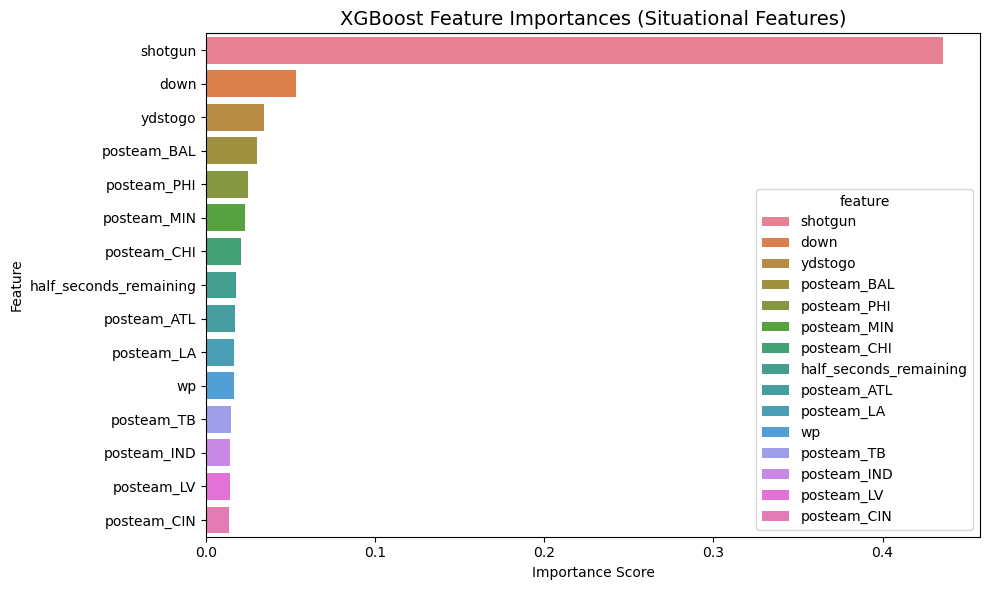

In [45]:
# getting feature importances from xgboost
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', 
            hue='feature', palette='husl', legend=True)
plt.title('XGBoost Feature Importances (Situational Features)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

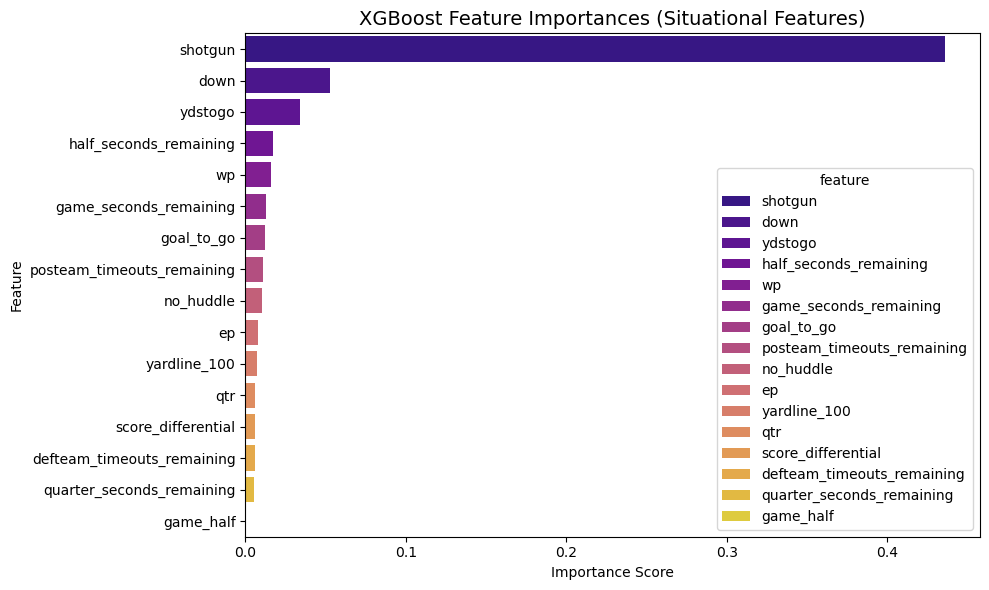

In [46]:
# getting the feature importances while excluding team columns
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
})

importance_df = importance_df[~importance_df['feature'].isin(team_cols)] \
    .sort_values('importance', ascending=False)

# plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', 
            hue='feature', palette='plasma', legend=True)
plt.title('XGBoost Feature Importances (Situational Features)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

<Figure size 800x600 with 0 Axes>

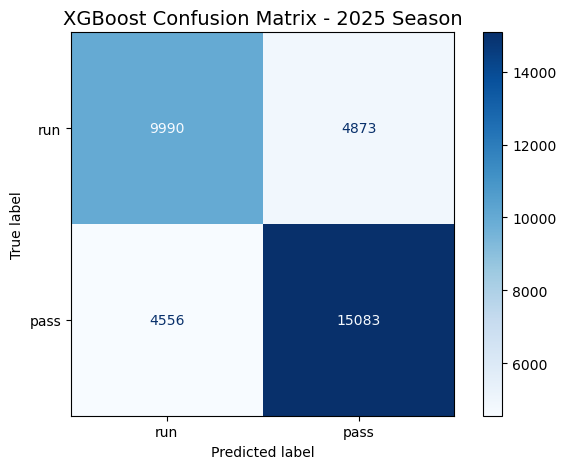

In [48]:
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['run', 'pass'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', colorbar=True)
plt.title('XGBoost Confusion Matrix - 2025 Season', fontsize=14)
plt.tight_layout()
plt.show()

Interestingly, the model is wrong on runs and passes at about the same rates (~33%). This suggests that it is heavily biased towards either class. 

The model is also especially good at prediciting passes. It correctly guessed 15,083 passes compared to the 9,990 runs that it predicted.

ADD LATER: Two Point Attempt column. That would be especially interesting to see, since it is the same down and distance every time, yet there are different game scenarios that could impact whether a team runs or passes. It might be a unique scenario that strays from the trend. I could also implement a team vs league average passing attempt on Two Pointers.

For 2016-2025:
- Logistic Regression: 0.7120456785113907
- Random Forest:       0.7127992580140282
- XGBoost:             0.7254941742507681


For 2019-2025:
- Logistic Regression: 0.7129731609761752
- Random Forest:       0.715291867138137
- XGBoost:             0.726827430293896

For 2021-2025:
- Logistic Regression: 0.7149730450408672
- Random Forest:       0.7158425598516028
- XGBoost:             0.7267114949857979

In [ ]:
import pathlib

model_path = pathlib.Path("../models/xgb_run_pass_model.json")
model_path.parent.mkdir(parents=True, exist_ok=True)
xgb_model.save_model(model_path)
print(f"Saved model to {model_path.resolve()}")